In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier


In [7]:
X = np.load('../Feature_Generation/fingerprints/X_train_morgan_fp.npy')
X_test_fp  = np.load('../Feature_Generation/fingerprints/X_test_morgan_fp.npy')
y    = np.load('../Feature_Generation/fingerprints/y_train.npy')

In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (202895, 1024)
y shape: (202895,)


In [9]:
Xtr, Xva, ytr, yva = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [10]:
# logistic regression model
model_LR = LogisticRegression(
    max_iter=200,
    class_weight="balanced",
    n_jobs=-1,
    solver="lbfgs"
)

# fit
model_LR.fit(Xtr, ytr)

# validation AUC
va_pred_lr = model_LR.predict_proba(Xva)[:, 1]
log_val_auc = roc_auc_score(yva, va_pred_lr)
print("Logistic Regression Validation AUC:", log_val_auc)

Logistic Regression Validation AUC: 0.8892546928767946


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [12]:
# cross-validation
log_cv_scores = cross_val_score(
    model_LR,
    X, y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("LogReg CV AUC mean ± std:", 
      log_cv_scores.mean(), log_cv_scores.std())

LogReg CV AUC mean ± std: 0.8852760234428263 0.0074124145908648


In [13]:
# Random Forest model
model_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=1,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=42,
    oob_score=False,
)

model_rf.fit(Xtr, ytr)

va_pred_rf = model_rf.predict_proba(Xva)[:, 1]
rf_val_auc  = roc_auc_score(yva, va_pred_rf)
print("Random Forest Validation AUC:", rf_val_auc)

Random Forest Validation AUC: 0.9360214218408023


In [14]:
rf_cv_scores = cross_val_score(
    model_rf,
    X, y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("RandomForest CV AUC mean ± std:",
      rf_cv_scores.mean(), rf_cv_scores.std())

RandomForest CV AUC mean ± std: 0.9356425460053698 0.004108101015310228


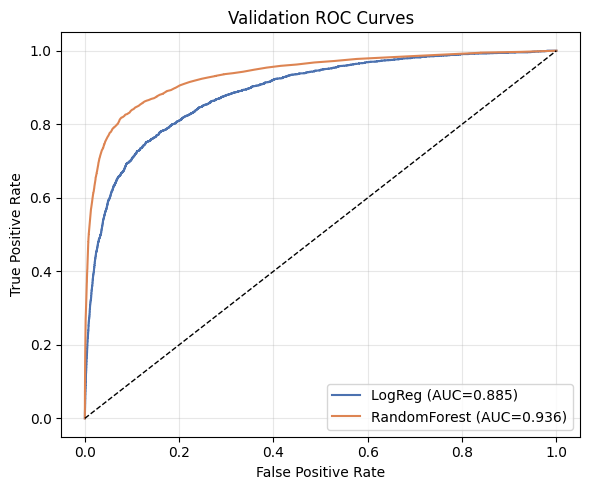

In [15]:
 # ROC curves
fpr_log, tpr_log, _ = roc_curve(yva, va_pred_lr)
fpr_rf,  tpr_rf,  _ = roc_curve(yva, va_pred_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label=f"LogReg (AUC={log_cv_scores.mean():.3f})", color="#4c72b0")
plt.plot(fpr_rf,  tpr_rf,  label=f"RandomForest (AUC={rf_cv_scores.mean():.3f})", color="#dd8452")
plt.plot([0,1], [0,1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("validation_roc_Morgan_Fingerprint.png", dpi=300, bbox_inches="tight")
plt.show()


In [17]:
#train all datas
best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=1,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=42,
    oob_score=False,
)

best_rf.fit(X, y) 

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
test_pred = best_rf.predict_proba(X_test_fp)[:, 1]
print("Test predictions shape:", test_pred.shape)

Test predictions shape: (67631,)


In [19]:
#17.txt
auc_est = 0.936 #the AUC
#put them together into a vector
values = np.concatenate([[auc_est], test_pred])

np.savetxt("17.txt", values, fmt="%.10g")

In [20]:
#controll the file

predictions_df = pd.read_csv("17.txt", header=None)

print("Shape:", predictions_df.shape)
assert predictions_df.shape == (X_test_fp.shape[0] + 1, 1)
assert np.all((predictions_df.values >= 0) & (predictions_df.values <= 1))

print("File looks good")

Shape: (67632, 1)
File looks good
